# Sífilis em Ilhéus e Itabuna - análise descritiva e demográfica

Este notebook descreve o perfil dos registros por cidade, tipo de sífilis, sexo, idade, raça/cor, escolaridade, gestação e idade materna.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def encontrar_projeto():
    for candidato in [Path.cwd(), *Path.cwd().parents]:
        if (candidato / "Dados").exists() and (candidato / "Sifilis").exists():
            return candidato
        if (candidato / "DataSUS" / "Dados").exists():
            return candidato / "DataSUS"
    raise FileNotFoundError("Não foi possível localizar a pasta DataSUS.")

PROJECT_DIR = encontrar_projeto()
SIFILIS_DIR = PROJECT_DIR / "Sifilis"
DATA_DIR = PROJECT_DIR / "Dados"
OUTPUT_DIR = SIFILIS_DIR / "dados_processados"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(SIFILIS_DIR) not in sys.path:
    sys.path.insert(0, str(SIFILIS_DIR))

from sifilis_utils import (
    ANOS_ESPERADOS,
    CODIGOS_CIDADES,
    TIPOS_SIFILIS,
    carregar_agregados_demograficos,
    carregar_agregados_especificos,
    carregar_agregados_qualidade,
    carregar_agregados_temporais,
    carregar_base_cidades,
    caminho_artefato,
    exigir_cache_processado,
    exibir_markdown,
    formatar_inteiro,
    formatar_percentual,
    ler_tabela,
    salvar_figura,
    verificar_cache_processado,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["font.size"] = 10

exigir_cache_processado(OUTPUT_DIR)

df_cidades = carregar_base_cidades(OUTPUT_DIR)
demo = carregar_agregados_demograficos(OUTPUT_DIR)
resumo_demo = demo["sifilis_demo_resumo"]
sexo_tab = demo["sifilis_demo_sexo"]
faixa_tab = demo["sifilis_demo_faixa_etaria"]
piramide = demo["sifilis_demo_piramide"]
raca_tab = demo["sifilis_demo_raca_cor"]
escolaridade_tab = demo["sifilis_demo_escolaridade"]
gestante_tab = demo["sifilis_demo_gestacao"]
idade_hist = demo["sifilis_demo_idade_histograma"]
idade_mae_hist = demo["sifilis_demo_idade_mae_histograma"]
pre_natal = demo["sifilis_demo_pre_natal_congenita"]
idade_mediana_tipo = demo["sifilis_demo_idade_mediana_tipo"]

In [2]:
resumo_demo

,cidade,tipo_sifilis,registros,idade_mediana
0,Ilhéus,Sífilis adquirida,714,32.0
1,Ilhéus,Sífilis congênita,316,0.0
2,Ilhéus,Sífilis em gestante,564,23.0
3,Itabuna,Sífilis adquirida,1495,34.0
4,Itabuna,Sífilis congênita,116,0.0
5,Itabuna,Sífilis em gestante,605,24.0


## Distribuição por tipo, cidade e sexo

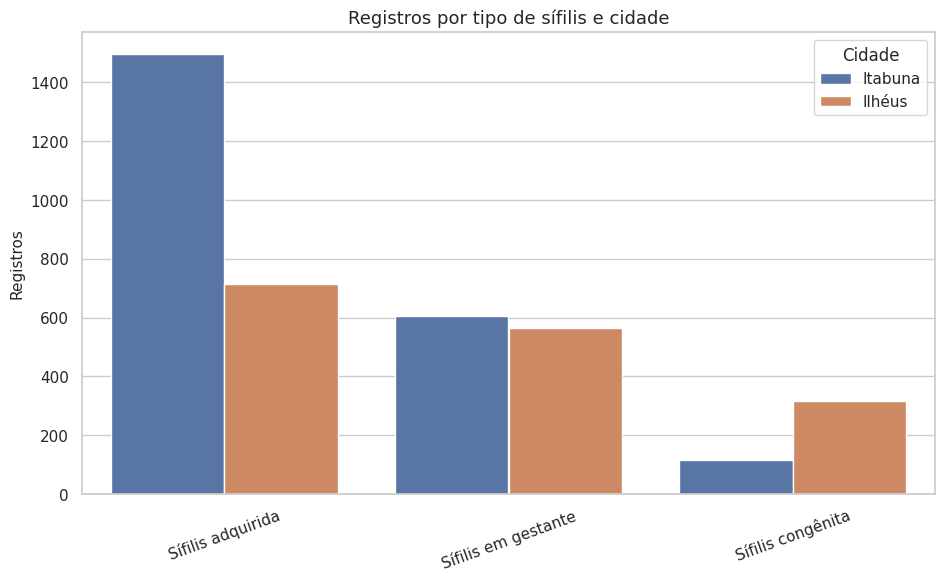

In [4]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.countplot(data=df_cidades, x="tipo_sifilis", hue="cidade", ax=ax)
ax.set_title("Registros por tipo de sífilis e cidade")
ax.set_xlabel("")
ax.set_ylabel("Registros")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Cidade")
salvar_figura(fig, OUTPUT_DIR, "03_tipo_cidade.png")
plt.show()

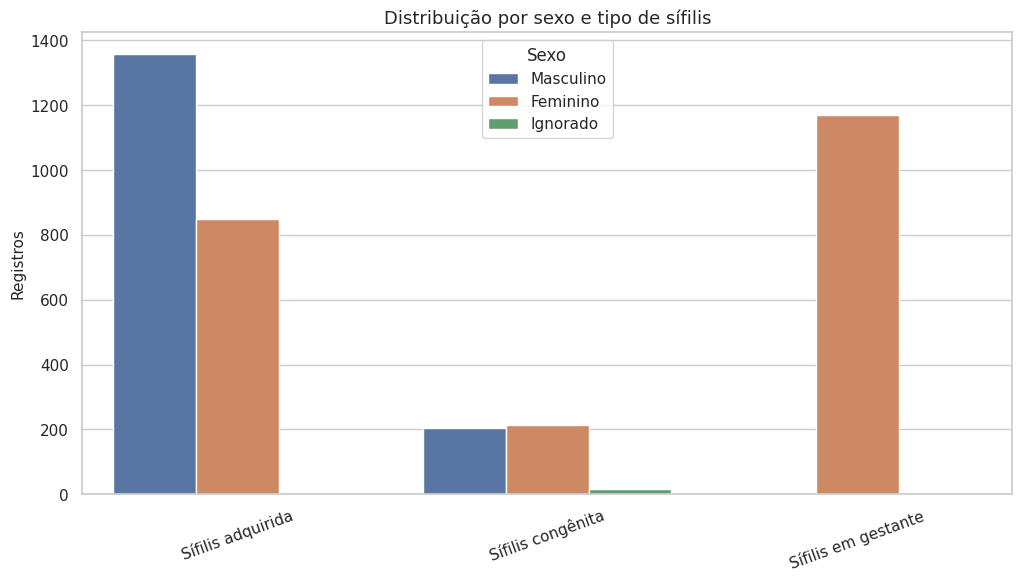

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=sexo_tab, x="tipo_sifilis", y="registros", hue="categoria", ax=ax)
ax.set_title("Distribuição por sexo e tipo de sífilis")
ax.set_xlabel("")
ax.set_ylabel("Registros")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Sexo")
salvar_figura(fig, OUTPUT_DIR, "03_sexo_tipo.png")
plt.show()

## Idade e faixa etária

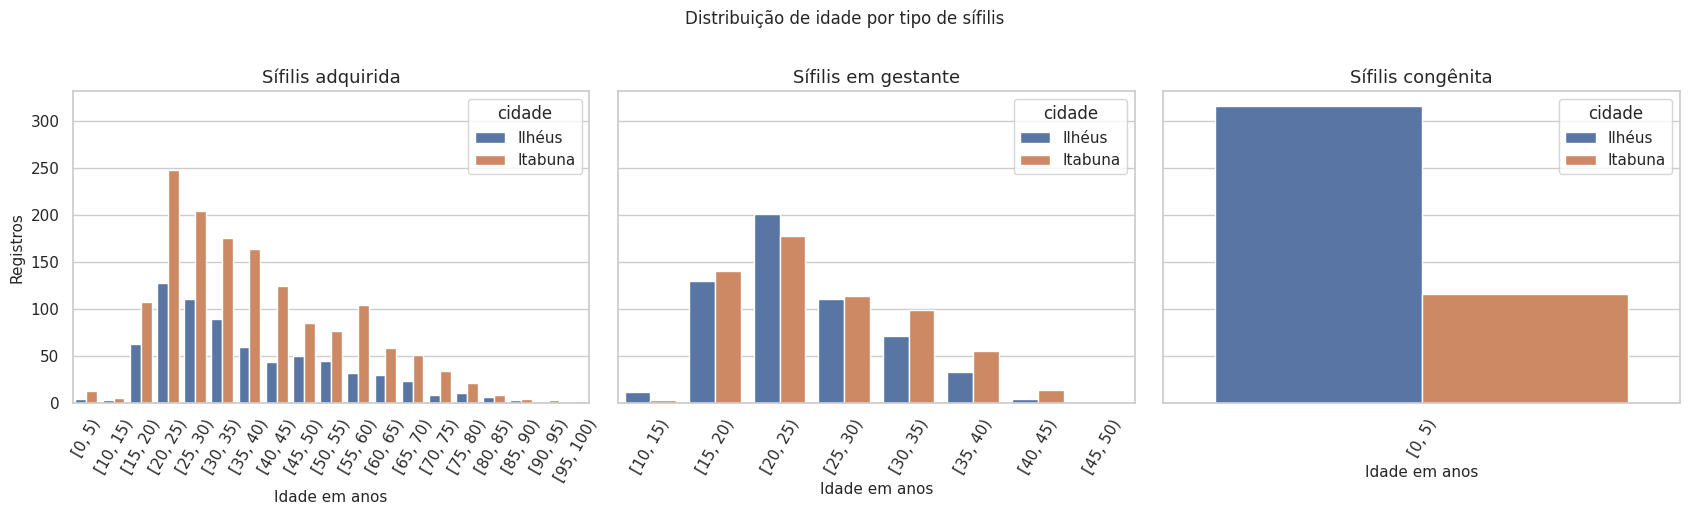

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for ax, tipo in zip(axes, TIPOS_SIFILIS.values()):
    base = idade_hist[(idade_hist["tipo_sifilis"] == tipo) & idade_hist["idade_bin"].notna()]
    sns.barplot(data=base, x="idade_bin", y="registros", hue="cidade", ax=ax)
    ax.set_title(tipo)
    ax.set_xlabel("Idade em anos")
    ax.set_ylabel("Registros")
    ax.tick_params(axis="x", rotation=60)
fig.suptitle("Distribuição de idade por tipo de sífilis", y=1.02)
fig.tight_layout()
salvar_figura(fig, OUTPUT_DIR, "03_idade_histogramas.png")
plt.show()

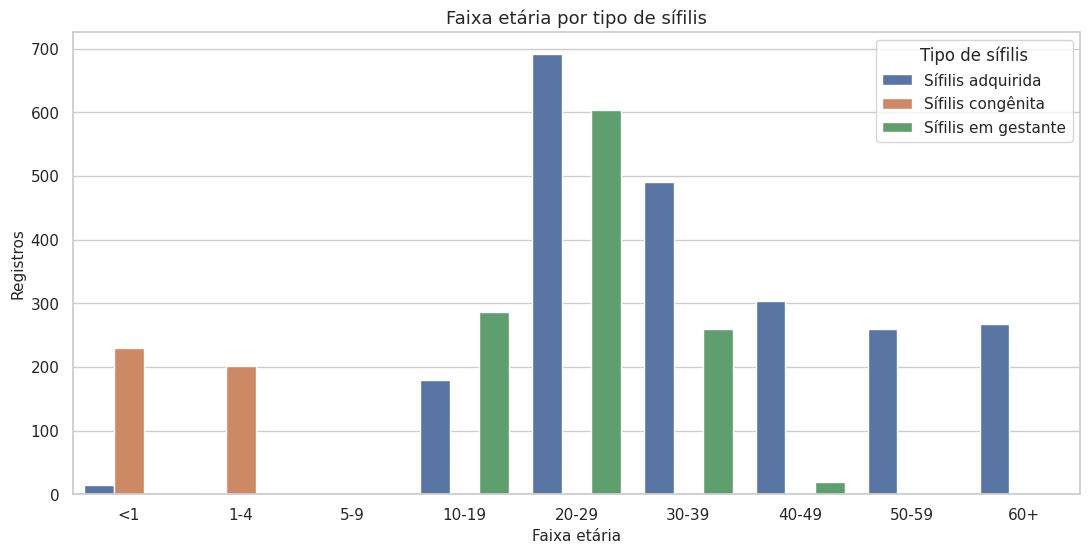

In [7]:
faixa_ordem = ["<1", "1-4", "5-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60+"]
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=faixa_tab, x="faixa_etaria", y="registros", hue="tipo_sifilis", order=faixa_ordem, ax=ax)
ax.set_title("Faixa etária por tipo de sífilis")
ax.set_xlabel("Faixa etária")
ax.set_ylabel("Registros")
ax.legend(title="Tipo de sífilis")
salvar_figura(fig, OUTPUT_DIR, "03_faixa_etaria_tipo.png")
plt.show()

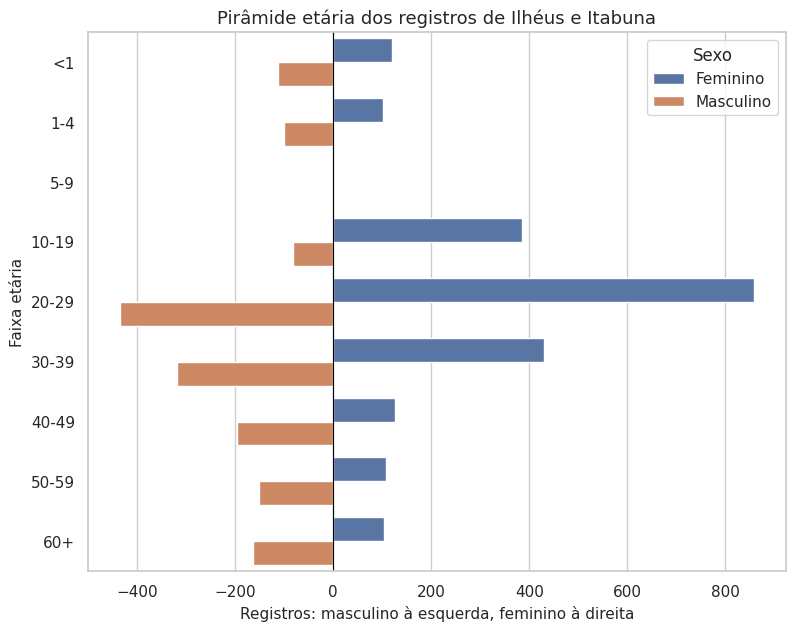

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=piramide, y="faixa_etaria", x="valor", hue="sexo", order=faixa_ordem, ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pirâmide etária dos registros de Ilhéus e Itabuna")
ax.set_xlabel("Registros: masculino à esquerda, feminino à direita")
ax.set_ylabel("Faixa etária")
ax.legend(title="Sexo")
salvar_figura(fig, OUTPUT_DIR, "03_piramide_etaria.png")
plt.show()

## Raça/cor e escolaridade

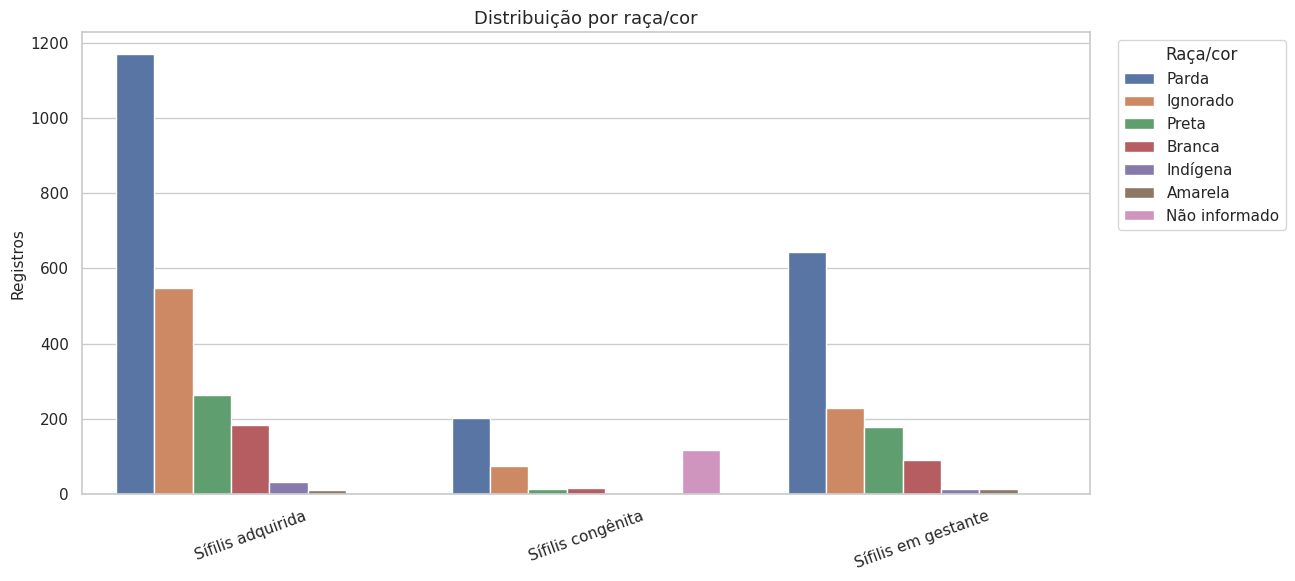

In [9]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=raca_tab, x="tipo_sifilis", y="registros", hue="categoria", ax=ax)
ax.set_title("Distribuição por raça/cor")
ax.set_xlabel("")
ax.set_ylabel("Registros")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Raça/cor", bbox_to_anchor=(1.02, 1), loc="upper left")
salvar_figura(fig, OUTPUT_DIR, "03_raca_cor.png")
plt.show()

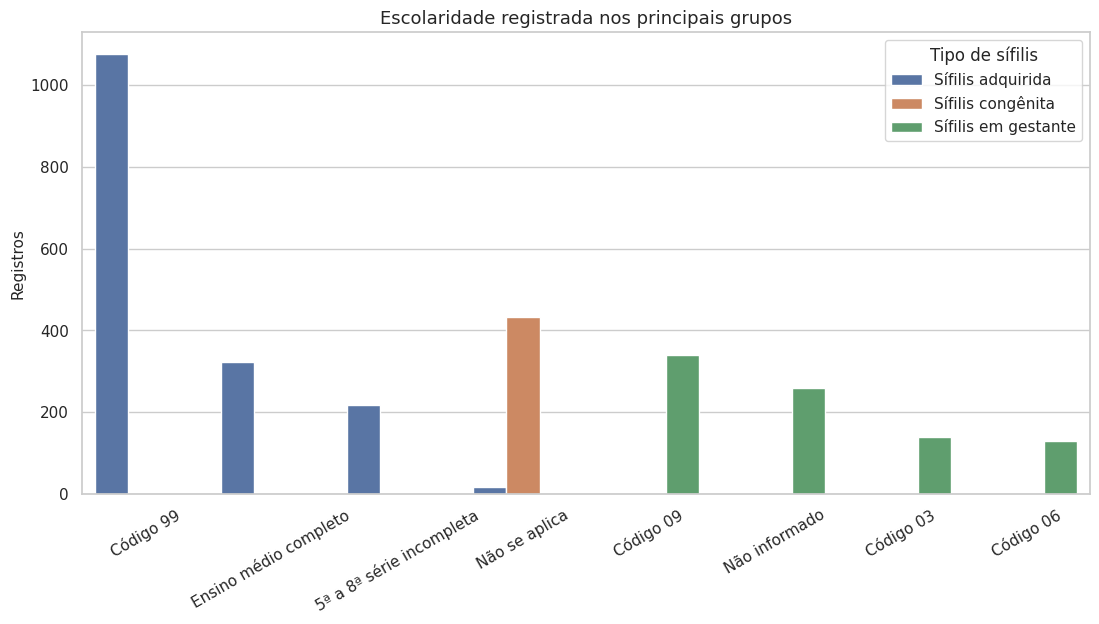

In [10]:
top_escolaridade = escolaridade_tab.groupby("categoria")["registros"].sum().sort_values(ascending=False).head(8).index
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=escolaridade_tab[escolaridade_tab["categoria"].isin(top_escolaridade)], x="categoria", y="registros", hue="tipo_sifilis", ax=ax)
ax.set_title("Escolaridade registrada nos principais grupos")
ax.set_xlabel("")
ax.set_ylabel("Registros")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Tipo de sífilis")
salvar_figura(fig, OUTPUT_DIR, "03_escolaridade.png")
plt.show()

## Gestação, idade materna e pré-natal

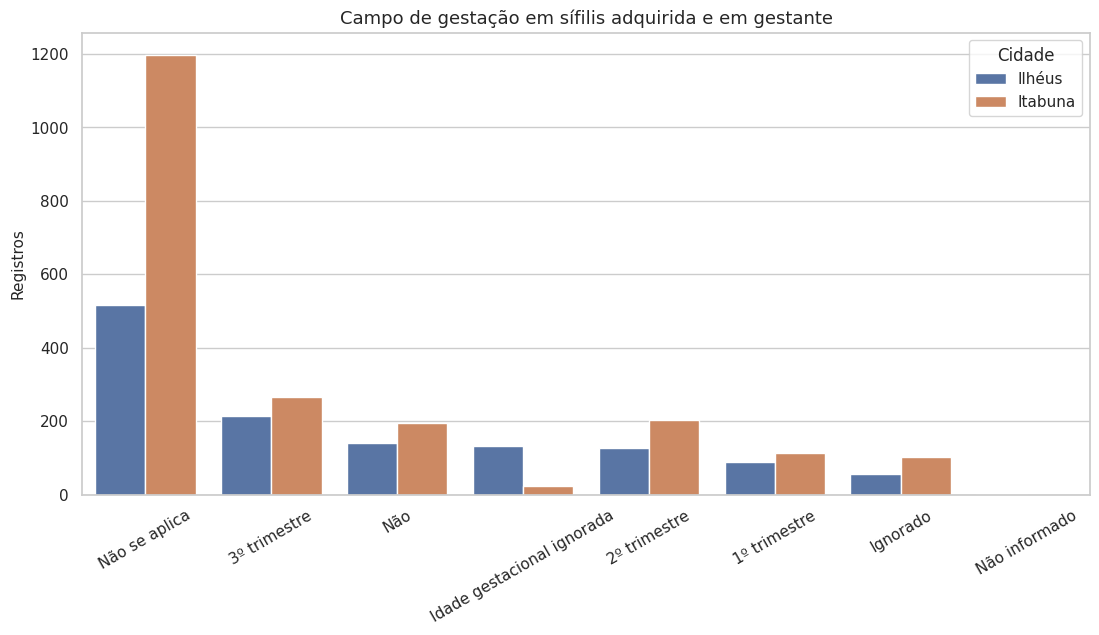

In [11]:
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=gestante_tab, x="categoria", y="registros", hue="cidade", ax=ax)
ax.set_title("Campo de gestação em sífilis adquirida e em gestante")
ax.set_xlabel("")
ax.set_ylabel("Registros")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Cidade")
salvar_figura(fig, OUTPUT_DIR, "03_gestacao.png")
plt.show()

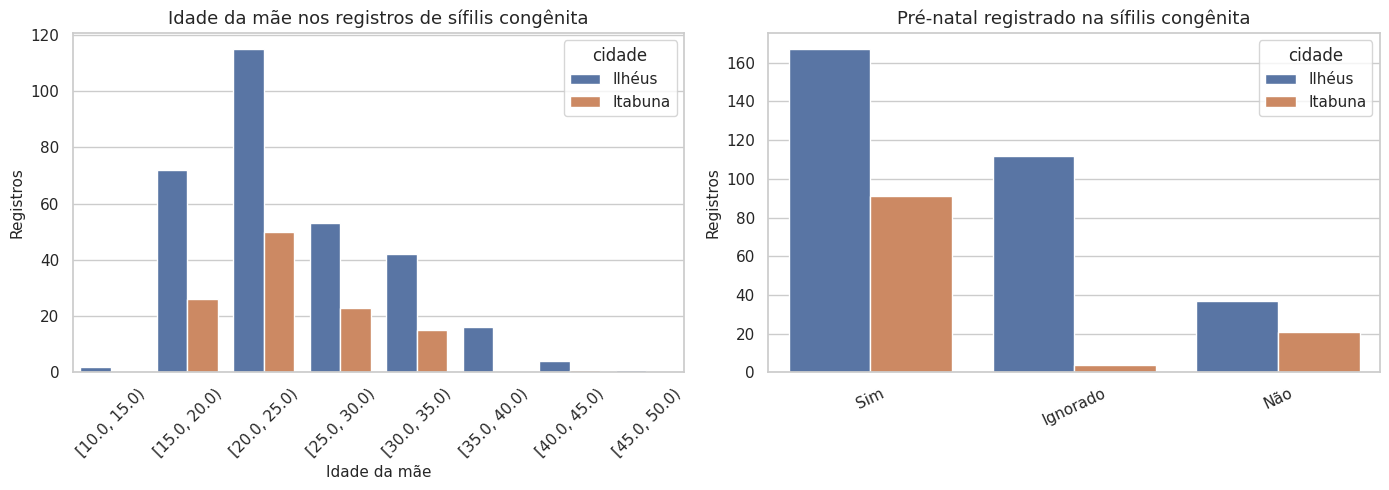

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=idade_mae_hist[idade_mae_hist["idade_mae_bin"].notna()], x="idade_mae_bin", y="registros", hue="cidade", ax=axes[0])
axes[0].set_title("Idade da mãe nos registros de sífilis congênita")
axes[0].set_xlabel("Idade da mãe")
axes[0].set_ylabel("Registros")
axes[0].tick_params(axis="x", rotation=45)
sns.barplot(data=pre_natal, x="categoria", y="registros", hue="cidade", ax=axes[1])
axes[1].set_title("Pré-natal registrado na sífilis congênita")
axes[1].set_xlabel("")
axes[1].set_ylabel("Registros")
axes[1].tick_params(axis="x", rotation=25)
fig.tight_layout()
salvar_figura(fig, OUTPUT_DIR, "03_idade_mae_pre_natal.png")
plt.show()

In [13]:
idade_mediana_por_tipo = idade_mediana_tipo.set_index("tipo_sifilis")["idade_mediana"].dropna().sort_values()
texto_idades = "; ".join([f"{tipo}: {valor:.1f} anos" for tipo, valor in idade_mediana_por_tipo.items()])
exibir_markdown(f"""
### Observações demográficas

As medianas de idade no recorte são: {texto_idades}. Para sífilis congênita, a idade da mãe é analisada separadamente porque a idade do registro se refere ao caso notificado e não substitui a informação materna.
""")


### Observações demográficas

As medianas de idade no recorte são: Sífilis congênita: 0.0 anos; Sífilis em gestante: 23.0 anos; Sífilis adquirida: 34.0 anos. Para sífilis congênita, a idade da mãe é analisada separadamente porque a idade do registro se refere ao caso notificado e não substitui a informação materna.
